#  Model Training and Comparison -Day

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the feature engineered dataset
df = pd.read_csv('day_dataset_featured_new.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Dataset loaded successfully!
Dataset shape: (731, 20)

First few rows:


,atemp,day_sin,holiday,hum,humidity_windspeed,is_weekend,mnth_cos,mnth_sin,season_4,temp,temp_comfort,temp_humidity,temp_squared,weather_temp_interaction,weekday_cos,weekday_sin,windspeed,workingday,yr,cnt
0,0.363625,0.201299,0,0.805833,0.129293,1,0.866025,0.5,0,0.344167,0.066826,0.277341,0.118451,0.277341,0.623490,-0.781831,0.160446,0,0,985
1,0.353739,0.394356,0,0.696087,0.173005,1,0.866025,0.5,0,0.363478,0.110466,0.253012,0.132116,0.253012,1.000000,0.000000,0.248539,0,0,801
2,0.189405,0.571268,0,0.437273,0.108579,0,0.866025,0.5,0,0.196364,0.110499,0.085865,0.038559,0.085865,0.623490,0.781831,0.248309,1,0,1349
3,0.212122,0.724793,0,0.590435,0.094644,0,0.866025,0.5,0,0.200000,0.081913,0.118087,0.040000,0.118087,-0.222521,0.974928,0.160296,1,0,1562
4,0.229270,0.848644,0,0.436957,0.081667,0,0.866025,0.5,0,0.226957,0.127787,0.099170,0.051509,0.099170,-0.900969,0.433884,0.186900,1,0,1600


In [3]:
# Check dataset information
print("Dataset Information:")
print(df.info())
print("\n" + "="*50)
print("\nDataset Statistics:")
print(df.describe())
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   atemp                     731 non-null    float64
 1   day_sin                   731 non-null    float64
 2   holiday                   731 non-null    int64  
 3   hum                       731 non-null    float64
 4   humidity_windspeed        731 non-null    float64
 5   is_weekend                731 non-null    int64  
 6   mnth_cos                  731 non-null    float64
 7   mnth_sin                  731 non-null    float64
 8   season_4                  731 non-null    int64  
 9   temp                      731 non-null    float64
 10  temp_comfort              731 non-null    float64
 11  temp_humidity             731 non-null    float64
 12  temp_squared              731 non-null    float64
 13  weather_temp_interaction  731 non-null    fl

In [ ]:
# Separate features and target variable
# Assuming 'cnt' is the target variable (total bike rentals)
target_column = 'cnt'
# Check if target column exists
if target_column not in df.columns:
    print(f"Available columns: {df.columns.tolist()}")
    print(f"\nPlease identify the target column from above")
else:
    X = df.drop(columns=[target_column])
    y = df[target_column]

    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"\nFeature columns: {X.columns.tolist()}")

Features shape: (731, 19)
Target shape: (731,)

Feature columns: ['atemp', 'day_sin', 'holiday', 'hum', 'humidity_windspeed', 'is_weekend', 'mnth_cos', 'mnth_sin', 'season_4', 'temp', 'temp_comfort', 'temp_humidity', 'temp_squared', 'weather_temp_interaction', 'weekday_cos', 'weekday_sin', 'windspeed', 'workingday', 'yr']


In [5]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Feature scaling (important for  Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData preprocessing completed!")

Training set size: 584 samples
Testing set size: 147 samples

Data preprocessing completed!


## Linear Regression

In [6]:
print("="*60)
print("LINEAR REGRESSION")
print("="*60)

# Initialize and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test_scaled)

# Calculate metrics
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("\nLinear Regression Results:")
print(f"Mean Squared Error (MSE): {lr_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {lr_mae:.2f}")
print(f"R² Score: {lr_r2:.4f}")
print("\n" + "="*60)

LINEAR REGRESSION

Linear Regression Results:
Mean Squared Error (MSE): 661229.43
Root Mean Squared Error (RMSE): 813.16
Mean Absolute Error (MAE): 592.64
R² Score: 0.8351



## Random Forest Regressor

In [7]:
print("="*60)
print("RANDOM FOREST REGRESSOR")
print("="*60)

# Initialize and train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)  # Random Forest doesn't require scaled data

# Make predictions
rf_pred = rf_model.predict(X_test)

# Calculate metrics
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Results:")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f}")
print(f"R² Score: {rf_r2:.4f}")
print("\n" + "="*60)

RANDOM FOREST REGRESSOR



Random Forest Results:
Mean Squared Error (MSE): 453259.80
Root Mean Squared Error (RMSE): 673.25
Mean Absolute Error (MAE): 439.79
R² Score: 0.8870



## XGBoost Regressor

In [8]:
print("="*60)
print("XGBOOST REGRESSOR")
print("="*60)

# Initialize and train XGBoost model
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, learning_rate=0.1, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

# Calculate metrics
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("\nXGBoost Results:")
print(f"Mean Squared Error (MSE): {xgb_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {xgb_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {xgb_mae:.2f}")
print(f"R² Score: {xgb_r2:.4f}")
print("\n" + "="*60)

XGBOOST REGRESSOR

XGBoost Results:
Mean Squared Error (MSE): 382509.47
Root Mean Squared Error (RMSE): 618.47
Mean Absolute Error (MAE): 419.85
R² Score: 0.9046



In [9]:
# Persist trained XGBoost model to disk
import pickle

model_path = "xgb_day_new.pkl"
with open(model_path, "wb") as f:
    pickle.dump(xgb_model, f)

print(f"Saved XGBoost model to {model_path}")

Saved XGBoost model to xgb_day_new.pkl


## LightGBM Regressor

In [10]:
print("="*60)
print("LIGHTGBM REGRESSOR")
print("="*60)

# Initialize and train LightGBM model
lgb_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, learning_rate=0.1, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)

# Make predictions
lgb_pred = lgb_model.predict(X_test)

# Calculate metrics
lgb_mse = mean_squared_error(y_test, lgb_pred)
lgb_rmse = np.sqrt(lgb_mse)
lgb_mae = mean_absolute_error(y_test, lgb_pred)
lgb_r2 = r2_score(y_test, lgb_pred)

print("\nLightGBM Results:")
print(f"Mean Squared Error (MSE): {lgb_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {lgb_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {lgb_mae:.2f}")
print(f"R² Score: {lgb_r2:.4f}")
print("\n" + "="*60)

LIGHTGBM REGRESSOR

LightGBM Results:
Mean Squared Error (MSE): 394754.99
Root Mean Squared Error (RMSE): 628.30
Mean Absolute Error (MAE): 420.40
R² Score: 0.9016



## Gradient Boosting Regressor

In [11]:
print("="*60)
print("GRADIENT BOOSTING REGRESSOR")
print("="*60)

# Initialize and train Gradient Boosting model
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, learning_rate=0.1)
gb_model.fit(X_train, y_train)

# Make predictions
gb_pred = gb_model.predict(X_test)

# Calculate metrics
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("\nGradient Boosting Results:")
print(f"Mean Squared Error (MSE): {gb_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {gb_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {gb_mae:.2f}")
print(f"R² Score: {gb_r2:.4f}")
print("\n" + "="*60)

GRADIENT BOOSTING REGRESSOR

Gradient Boosting Results:
Mean Squared Error (MSE): 403188.04
Root Mean Squared Error (RMSE): 634.97
Mean Absolute Error (MAE): 444.20
R² Score: 0.8995



##  Model Comparison and Visualization

In [12]:
# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'Gradient Boosting'],
    'MSE': [lr_mse, rf_mse, xgb_mse, lgb_mse, gb_mse],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse, lgb_rmse, gb_rmse],
    'MAE': [lr_mae, rf_mae, xgb_mae, lgb_mae, gb_mae],
    'R² Score': [lr_r2, rf_r2, xgb_r2, lgb_r2, gb_r2]
})

print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON TABLE
            Model           MSE       RMSE        MAE  R² Score
Linear Regression 661229.427881 813.160149 592.639542  0.835100
    Random Forest 453259.799222 673.245720 439.790068  0.886964
          XGBoost 382509.468750 618.473499 419.847778  0.904608
         LightGBM 394754.989535 628.295304 420.404900  0.901554
Gradient Boosting 403188.042387 634.970899 444.204848  0.899451


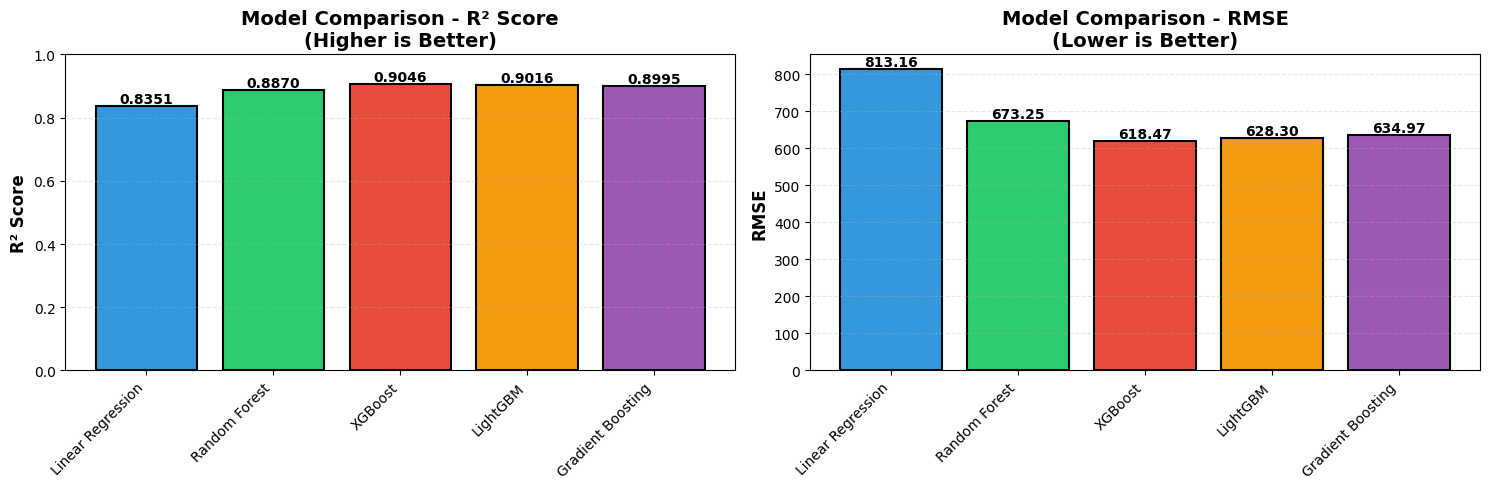

In [ ]:
# Visualize model comparison - R² Score
plt.figure(figsize=(15, 5))

# Plot 1: R² Score comparison
plt.subplot(1, 2, 1)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = plt.bar(comparison_df['Model'], comparison_df['R² Score'], color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.title('Model Comparison - R² Score\n(Higher is Better)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontweight='bold')

# Plot 2: RMSE comparison
plt.subplot(1, 2, 2)
bars = plt.bar(comparison_df['Model'], comparison_df['RMSE'], color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('RMSE', fontsize=12, fontweight='bold')
plt.title('Model Comparison - RMSE\n(Lower is Better)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# Find the best model based on R² score
best_model_idx = comparison_df['R² Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']
best_r2 = comparison_df.loc[best_model_idx, 'R² Score']
best_rmse = comparison_df.loc[best_model_idx, 'RMSE']

print("\n" + "="*80)
print("BEST MODEL")
print("="*80)
print(f"Best Model: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   RMSE: {best_rmse:.2f}")
print("\nExplanation:")
print(f"The {best_model_name} model performs the best with an R² score of {best_r2:.4f}.")
print("="*80)


BEST MODEL
Best Model: XGBoost
   R² Score: 0.9046
   RMSE: 618.47

Explanation:
The XGBoost model performs the best with an R² score of 0.9046.


## Actual vs Predicted Values Visualization

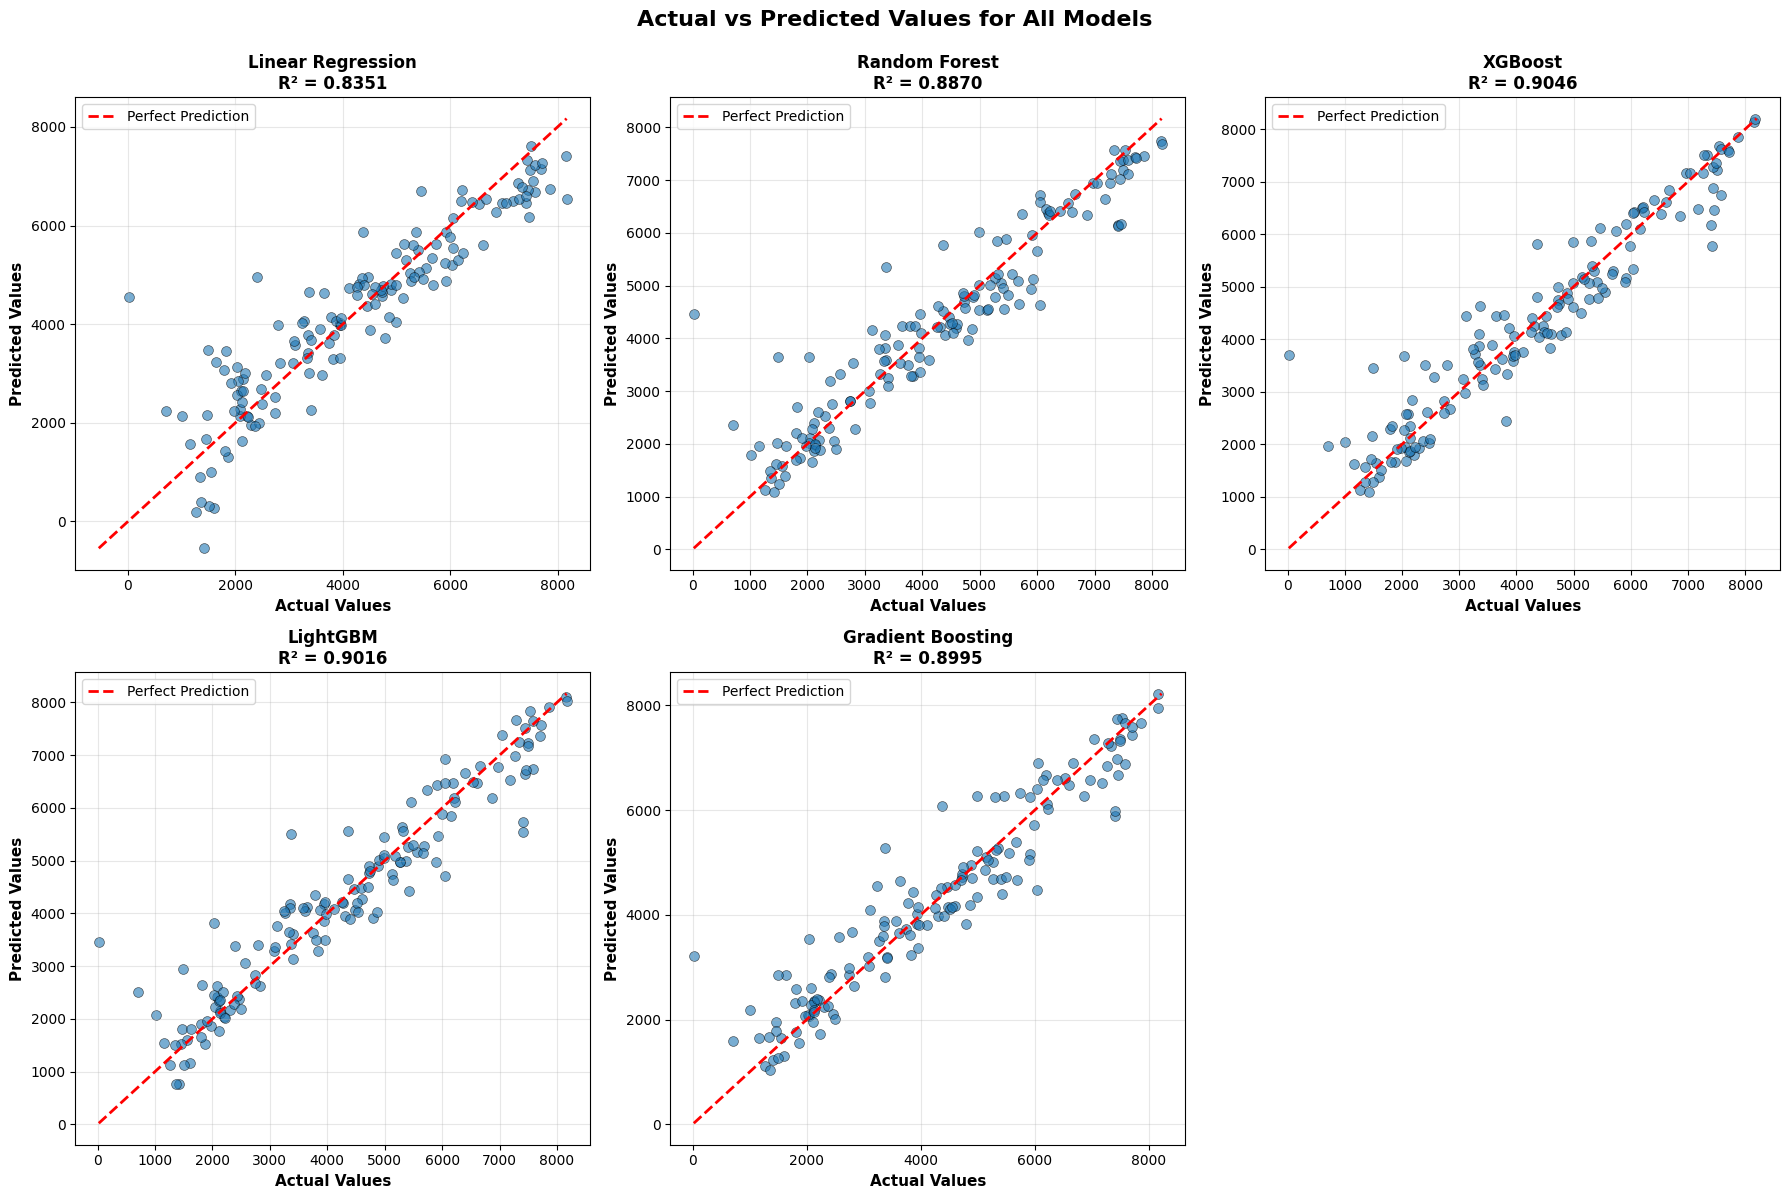

In [15]:
# Visualize Actual vs Predicted for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Actual vs Predicted Values for All Models', fontsize=16, fontweight='bold', y=0.995)

models = [
    ('Linear Regression', lr_pred, lr_r2),
    ('Random Forest', rf_pred, rf_r2),
    ('XGBoost', xgb_pred, xgb_r2),
    ('LightGBM', lgb_pred, lgb_r2),
    ('Gradient Boosting', gb_pred, gb_r2)
]

for idx, (name, predictions, r2) in enumerate(models):
    ax = axes[idx // 3, idx % 3]

    # Scatter plot
    ax.scatter(y_test, predictions, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

    # Perfect prediction line
    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    ax.set_xlabel('Actual Values', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted Values', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the last subplot (since we have 5 models, not 6)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()